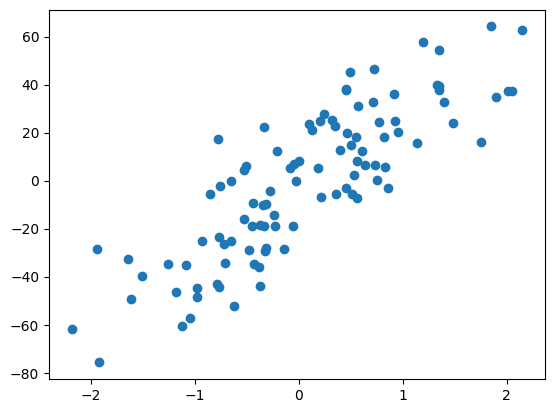

In [3]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)
plt.scatter(X,y)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)
# best tradeoff 
print("R2_score:",r2_score(rr.predict(X),y))

[24.9546267]
-2.1269130035235735
R2_score: 0.46267345921570935


In [5]:
rr1 = Ridge(alpha=100) 
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)
# underfitting
print("R2_score:",r2_score(rr1.predict(X),y))

[12.93442104]
-1.4248441496033308
R2_score: -2.2766183771822974


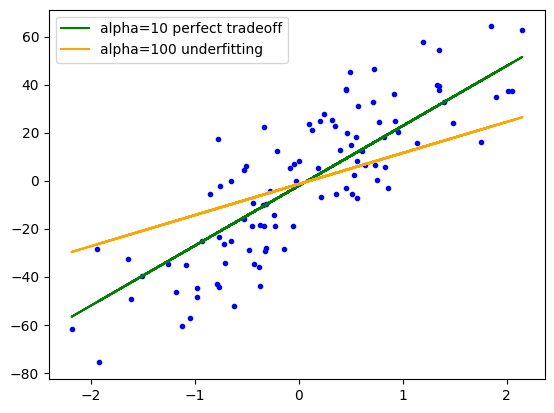

In [6]:
plt.plot(X,y,'b.')
plt.plot(X,rr.predict(X),color='green',label='alpha=10 perfect tradeoff')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100 underfitting')
plt.legend()

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

class ridgeClass:
    def __init__(self,alpha = 0.1):
        self.m = None
        self.b=None
        self.alpha = alpha
        
    def fit(self,X_train,y_train):
        num = 0
        denom = 0
        for i in range(X_train.shape[0]):
            num +=(( y_train[i] - y_train.mean())*(X_train[i] - X_train.mean()))
            denom += ((X_train[i] - X_train.mean())**2)
            
        self.m = num/(denom+self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        
        print(self.m,self.b)
        
    def predict(self,x_test):
        return self.m * x_test + self.b

In [18]:
rdg = ridgeClass(alpha=10)
rdg.fit(X_train,y_train)

[24.84312743] [-2.1047489]


In [19]:
print(rdg.m)
print(rdg.b)
print("R2_score:",r2_score(rdg.predict(X_test),y_test))

[24.84312743]
[-2.1047489]
R2_score: 0.390245866824945
